In [22]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from util import load_experiment, random_quantiles

In [26]:
model_3hr, dataset, config = load_experiment('a08a3931-edb3-4b01-a000-c4aef25ef2aa', '../../data/processed/dataset_clean.csv')
model_12hr, _, _ = load_experiment('1445762b-f54b-442d-9d88-2ae44955a2d1', '../../data/processed/dataset_clean.csv')

Time steps to predict: 24
torch.Size([1, 24, 16])
[0.00617398 0.01172822 0.00616236 0.00697537 0.0388378  0.05969693
 0.06088641 0.014536   0.05721802 0.04369159 0.06883163 0.03217331
 0.03194095 0.03508155 0.07007131 0.0185159  0.07006077 0.07053804
 0.02224238 0.02302624 0.0358067  0.0677039  0.07910419 0.03632534]
torch.Size([1, 24, 32])
[0.00734452 0.01185379 0.00585878 0.00557146 0.03651693 0.05720427
 0.05842789 0.01297458 0.05595383 0.04347993 0.06784192 0.03067271
 0.02989547 0.03230698 0.06715004 0.01600412 0.06734343 0.06816572
 0.02056365 0.02145959 0.03438655 0.06625707 0.07810232 0.03628502]


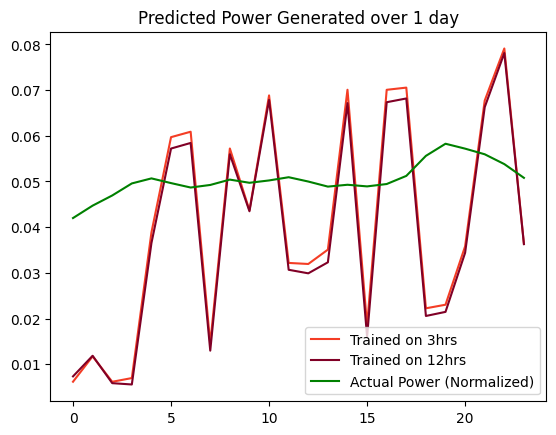

Time steps to predict: 168
torch.Size([1, 168, 16])
[ 0.03899305  0.05683977  0.0219742   0.00876897  0.03626331  0.03867656
  0.03303529  0.014536    0.06809363  0.0261941   0.06883163  0.07055546
  0.02032681  0.05666823  0.03453404  0.0185159   0.07006077  0.07053804
  0.07095763  0.04321909  0.07310458  0.04701364  0.05158409  0.07729188
  0.03356778  0.02991054  0.05608992  0.03483373  0.03515384  0.08236447
  0.06768875  0.05523713  0.03294376  0.04244414  0.07320966  0.02076096
  0.03640528  0.04470107  0.04562458  0.01128396  0.014027    0.02139492
  0.05718209  0.05441051  0.00308743  0.00211971  0.03434192  0.04861942
  0.05256752  0.00386389  0.0208487   0.01243869  0.00673379  0.00709301
  0.01057346  0.01086044  0.06323507  0.01964729  0.01750126  0.04030074
  0.06606027  0.05693742  0.01715967  0.04451127  0.01352393  0.05891807
  0.03006501  0.00805376  0.00471651  0.00204351  0.00029691 -0.00114801
  0.01297927  0.00026946  0.04258988  0.00467731 -0.00274246  0.02169178

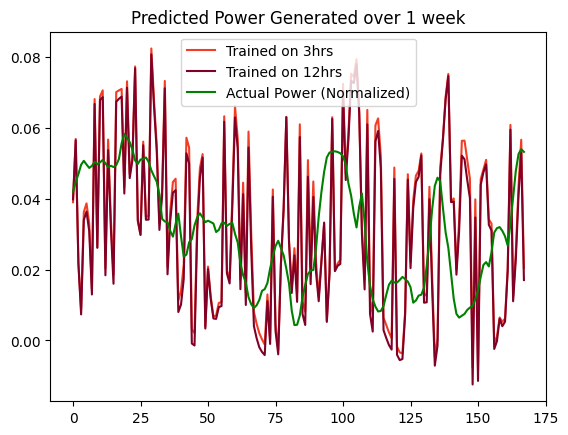

Time steps to predict: 720
torch.Size([1, 720, 16])
[ 6.17397716e-03  5.68397716e-02  2.98042223e-02  6.97536813e-03
  8.38088244e-03  2.42213737e-02  1.18921064e-02  6.34654164e-02
  6.80936277e-02  2.61940975e-02  2.00505797e-02  3.65284085e-02
  6.91011623e-02  6.69628084e-02  7.00713098e-02  6.73442855e-02
  7.00607747e-02  2.18094420e-02  7.09576309e-02  3.24262381e-02
  4.53392975e-02  4.71166112e-02  7.91041851e-02  6.18280433e-02
  3.35677788e-02  2.99105421e-02  3.68663222e-02  4.05380651e-02
  8.33990946e-02  7.68518448e-02  8.13823789e-02  7.99226388e-02
  3.29437591e-02  2.91275512e-02  2.45647263e-02  4.53624651e-02
  7.02801049e-02  1.89154744e-02  1.79032180e-02  6.03041910e-02
  6.09990694e-02  1.00564212e-02  1.39801130e-02  5.27146691e-03
  5.22631705e-02  2.11970741e-03  4.82880324e-02  9.34809819e-03
  3.40594864e-03  3.16651314e-02  3.17099430e-02  3.39419954e-02
  3.72046940e-02  5.61869107e-02  8.28445517e-03  1.08604375e-02
  6.32350743e-02  6.84324950e-02  1.75

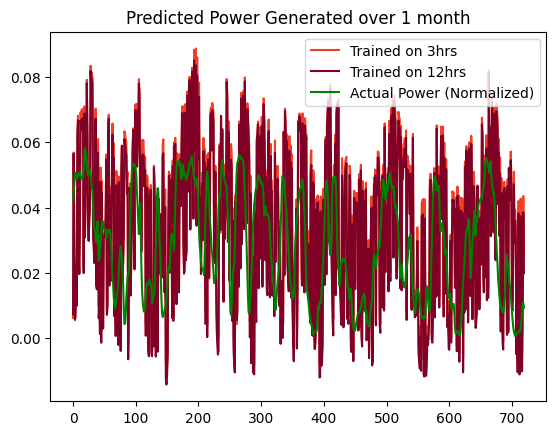

In [34]:
(speed, power) = dataset

models = [model_3hr, model_12hr]
model_labels = ['Trained on 3hrs', 'Trained on 12hrs']

scales = ['1 day', '1 week', '1 month']
upper_bounds = [24, 24 * 7, 24 * 30]

M = len(models)

for i in range(len(scales)):
    scale = scales[i]
    T = upper_bounds[i]
    x = np.arange(0, T)

    input = speed[:T].unsqueeze(0)
    target = power[:T]

    norm_speed = input.squeeze() / torch.max(input)
    cmap = plt.get_cmap('YlOrRd', M + 2)
    print(f'Time steps to predict: {T}')
    # Use same quantiles for all models to ensure "fairness" in visualizing predictions
    quantiles = random_quantiles(size=(T), lower=0.01, upper=0.99)
    for j in range(M):
        model = models[j]
        label = model_labels[j]
        predicted_power = model(input, quantiles).detach().cpu().numpy().squeeze()
        print(predicted_power)
        plt.plot(x, predicted_power, color=cmap(j+2), label=label)
    plt.plot(x, target, 'g', label='Actual Power (Normalized)')
    # plt.plot(x, norm_speed, '--b', label='Wind Speeds (Normalized)')
    plt.title(f'Predicted Power Generated over {scale}')
    plt.legend()
    plt.show()